# Tutorial: Calibrating Systematic Poking Material Parameters from Reaction Forces

**Goal**: fit Systematic Poking material parameters from a set of static
reaction-force curves so that the fitted material's reactions match a
Neo-Hookean target.

## Outline

1. Build a 2×2×2 hexahedral grid;
2. Construct the elastic energy (material definition / binding / state);
3. Define load cases (uniaxial + shear) and how reactions are read;
4. Static solve: find the equilibrium with a Newton optimizer;
5. Generate "ground truth" reactions with the target material;
6. Implicit differentiation: the reaction Jacobian w.r.t. material parameters;
7. Gauss-Newton fit in log space;
8. Results and visualization.


## 0. Setup

The cell below adds the repository root to `sys.path` so `pypgo` is importable
from any directory, and sets the C++ backend's log level to `off` so spdlog
does not flood the output. Everything from here on runs silently; call
`pypgo.set_log_level("info")` at any point to turn logging back on.


In [1]:
import sys
from pathlib import Path

REPO_ROOT = Path.cwd()
while not (REPO_ROOT / "pypgo").exists() and REPO_ROOT != REPO_ROOT.parent:
    REPO_ROOT = REPO_ROOT.parent
sys.path.insert(0, str(REPO_ROOT))

import numpy as np
import pypgo as pgo
import pypgo.fem as pf
import pypgo.solver as ps

# The C++ backend logs through spdlog to stdout; silence it for this notebook.
# Restore at any time with pgo.set_log_level("info").
pgo.set_log_level("off")


## 1. Experiment configuration and mesh

All experimental constants live at the top. The mesh is a unit cube split
into `GRID_SIZE^3` hexahedra (8 corners each) -- tiny, but enough to produce
meaningful reaction-force curves.

In [2]:
TARGET_E, TARGET_NU = 2.0e5, 0.35   # target Neo-Hookean material
INIT_E, INIT_NU = 1.2e5, 0.25       # starting guess for the fit
FORCE_SCALE = TARGET_E              # forces/parameters normalized by E
STATIC_TOL = 1.0e-6                 # equilibrium residual threshold
SMOOTHNESS = 1.0e-3                 # second-difference regularization weight
KNOT_COUNT = 17                     # stretch/volume knots (must be odd)
GRID_SIZE = 2                       # grid: divisions along each axis
SHEARS = (-0.8, -0.4, 0.4, 0.8)     # training shear magnitudes


def make_grid(n: int = GRID_SIZE):
    ids = np.arange((n + 1) ** 3).reshape((n + 1, n + 1, n + 1))
    vertices = np.array(
        [[i / n, j / n, k / n]
         for i in range(n + 1) for j in range(n + 1) for k in range(n + 1)],
        dtype=np.float64,
    )
    elements = np.array(
        [[ids[i, j, k], ids[i + 1, j, k], ids[i + 1, j + 1, k],
          ids[i, j + 1, k], ids[i, j, k + 1], ids[i + 1, j, k + 1],
          ids[i + 1, j + 1, k + 1], ids[i, j + 1, k + 1]]
         for i in range(n) for j in range(n) for k in range(n)],
        dtype=np.int64,
    )
    return vertices, elements


vertices, elements = make_grid()
print(f"vertices = {len(vertices)}   elements = {len(elements)}   "
      f"displacement dofs = {vertices.size}")

vertices = 27   elements = 8   displacement dofs = 81


## 2. Building the elastic energy

`pypgo`'s material system has two layers:

- **Fixed channels** (`MaterialBinding`): per-element constants such as E, nu;
- **Optimizable channels** (`MaterialState`): the values being fitted, e.g.
  Systematic Poking's f''(knot) values and lambda -- this is what the outer
  loop changes every iteration.

`make_energy(elastic, elastic_values)` combines both layers into a
`DeformationPotentialEnergy`. The target material (Neo-Hookean) has no
optimizable channels (empty array); the fitted material broadcasts the
current parameters to all elements.

In [3]:
def fixed_channel_block(elastic, num_elements):
    """Element-major fixed channels for the MaterialBinding."""
    if elastic.name == "neo_hookean":
        return np.tile([TARGET_E, TARGET_NU], (num_elements, 1))
    if elastic.name == "systematic_poking":
        # Knot locations live in the definition; no per-element fixed channels
        return np.empty((num_elements, 0), dtype=np.float64)
    raise ValueError(f"unsupported fixed channels for {elastic.name}")


def make_energy(elastic, elastic_values):
    """Build a CubicLinear deformation energy (values broadcast to all elements)."""
    volume = pgo.mesh.volume.VolumeMesh(
        pgo.mesh.CubicMeshData(*make_grid()),
        pgo.mesh.volume.ENuMaterial(E=TARGET_E, nu=TARGET_NU),
    )
    mesh = pf.SimulationMesh(volume)
    plastic = pf.VolumetricPlasticityDefinition(dofs=0)

    values = np.asarray(elastic_values, dtype=np.float64).reshape(-1)
    channels = elastic.num_optimizable_channels
    if values.size == channels:
        values = np.broadcast_to(
            values.reshape(1, channels),
            (mesh.num_elements, channels),
        ).copy()
    elif values.size != mesh.num_elements * channels:
        raise ValueError("elastic_values must be constant or elementwise")

    binding = pf.MaterialBinding(
        pf.ElasticMaterialBinding(
            elastic, mesh.num_elements,
            fixed_channel_block(elastic, mesh.num_elements)),
        pf.PlasticMaterialBinding(
            plastic, mesh.num_elements,
            np.empty((mesh.num_elements, 0), dtype=np.float64)),
    )
    operator = pf.DeformationEnergyOperator(
        mesh, binding,
        formulation=pf.CubicLinear(),
        options=pf.DeformationOptions(project_hessian_psd=False),
    )
    return pf.DeformationPotentialEnergy(operator, pf.MaterialState(values, np.empty(0)))

## 3. Load cases and reactions

Each load case is a set of **displacement boundary conditions** plus a
**reaction readout**:

- Uniaxial: bottom y fixed, top y compressed to `stretch`; `confined` also
  locks the sides, `free` adds only three minimal rigid pins;
- Shear: bottom fully fixed, top x translated by `shear`.

The reaction is `reaction_selector @ gradient`, i.e. the total force on the
top face: once the equilibrium is solved, the gradient *is* the reaction force.

In [4]:
from dataclasses import dataclass


@dataclass
class LoadCase:
    label: str
    protocol: str
    coordinate: float
    fixed_dofs: np.ndarray
    fixed_values: np.ndarray
    free_dofs: np.ndarray
    reaction_selector: np.ndarray
    initial_displacement: np.ndarray
    target: float = 0.0


def constraints_from_mapping(mapping, num_dofs):
    fixed_dofs = np.array(sorted(mapping), dtype=np.int64)
    fixed_values = np.array([mapping[int(d)] for d in fixed_dofs], dtype=np.float64)
    free_dofs = np.setdiff1d(np.arange(num_dofs, dtype=np.int64), fixed_dofs)
    return fixed_dofs, fixed_values, free_dofs


def free_uniaxial_pins(vertices, bottom):
    positions = vertices[bottom]
    centroid = positions.mean(axis=0)
    d2 = ((positions[:, 0] - centroid[0]) ** 2 +
          (positions[:, 2] - centroid[2]) ** 2)
    anchor = int(bottom[np.argmin(d2)])
    same_z = bottom[np.isclose(vertices[bottom, 2], vertices[anchor, 2])]
    candidates = same_z[same_z != anchor]
    if candidates.size == 0:
        candidates = bottom[bottom != anchor]
    rotation_pin = int(candidates[np.argmax(
        np.abs(vertices[candidates, 0] - vertices[anchor, 0]))])
    return anchor, rotation_pin


def _boundary_vertices(vertices):
    bottom = np.flatnonzero(np.isclose(vertices[:, 1], 0.0))
    top = np.flatnonzero(np.isclose(vertices[:, 1], 1.0))
    return bottom, top


def free_uniaxial_cases(vertices, stretches):
    """Bottom fixed in y; top compressed along y; three rigid pins on the bottom."""
    num_dofs = vertices.size
    bottom, top = _boundary_vertices(vertices)
    cases = []
    for stretch in stretches:
        mapping = {}
        for v in bottom:
            mapping[3 * int(v) + 1] = 0.0
        for v in top:
            mapping[3 * int(v) + 1] = stretch - 1.0
        anchor, rotation_pin = free_uniaxial_pins(vertices, bottom)
        mapping[3 * anchor] = 0.0
        mapping[3 * anchor + 2] = 0.0
        mapping[3 * rotation_pin + 2] = 0.0
        fixed_dofs, fixed_values, free_dofs = constraints_from_mapping(
            mapping, num_dofs)
        selector = np.zeros(num_dofs)
        selector[3 * top + 1] = 1.0
        initial = np.zeros(num_dofs)
        initial[1::3] = (stretch - 1.0) * vertices[:, 1]
        cases.append(LoadCase(
            label=f"free_uniaxial_{stretch:.3f}",
            protocol="free_uniaxial",
            coordinate=stretch,
            fixed_dofs=fixed_dofs, fixed_values=fixed_values,
            free_dofs=free_dofs, reaction_selector=selector,
            initial_displacement=initial))
    return cases


def confined_uniaxial_cases(vertices, stretches):
    """Bottom fixed in y; top compressed along y; all x/z DOFs pinned."""
    num_dofs = vertices.size
    bottom, top = _boundary_vertices(vertices)
    cases = []
    for stretch in stretches:
        mapping = {}
        for v in bottom:
            mapping[3 * int(v) + 1] = 0.0
        for v in top:
            mapping[3 * int(v) + 1] = stretch - 1.0
        for v in range(len(vertices)):
            mapping[3 * v] = 0.0
            mapping[3 * v + 2] = 0.0
        fixed_dofs, fixed_values, free_dofs = constraints_from_mapping(
            mapping, num_dofs)
        selector = np.zeros(num_dofs)
        selector[3 * top + 1] = 1.0
        initial = np.zeros(num_dofs)
        initial[1::3] = (stretch - 1.0) * vertices[:, 1]
        cases.append(LoadCase(
            label=f"confined_uniaxial_{stretch:.3f}",
            protocol="confined_uniaxial",
            coordinate=stretch,
            fixed_dofs=fixed_dofs, fixed_values=fixed_values,
            free_dofs=free_dofs, reaction_selector=selector,
            initial_displacement=initial))
    return cases


def simple_shear_cases(vertices, shears):
    """Bottom fully fixed; top translated along x by the shear amount."""
    num_dofs = vertices.size
    bottom, top = _boundary_vertices(vertices)
    cases = []
    for shear in shears:
        mapping = {}
        for v in bottom:
            for c in range(3):
                mapping[3 * int(v) + c] = 0.0
        for v in top:
            mapping[3 * int(v)] = shear
            mapping[3 * int(v) + 1] = 0.0
        fixed_dofs, fixed_values, free_dofs = constraints_from_mapping(
            mapping, num_dofs)
        selector = np.zeros(num_dofs)
        selector[3 * top] = 1.0
        initial = np.zeros(num_dofs)
        initial[0::3] = shear * vertices[:, 1]
        cases.append(LoadCase(
            label=f"simple_shear_{shear:+.3f}", protocol="simple_shear",
            coordinate=shear,
            fixed_dofs=fixed_dofs, fixed_values=fixed_values,
            free_dofs=free_dofs, reaction_selector=selector,
            initial_displacement=initial))
    return cases


def make_cases(vertices, knots):
    """Build the three protocol families explicitly and concatenate them."""
    stretches = [k for i, k in enumerate(knots) if i != len(knots) // 2]
    return (
        free_uniaxial_cases(vertices, stretches)
        + confined_uniaxial_cases(vertices, stretches)
        + simple_shear_cases(vertices, SHEARS)
    )


### A first look at the three load protocols

Before assembling the full training set, solve one representative case per
protocol with the experiment's dump helpers and render the surfaces with
`pgo.visualize`. Each case is shown next to the rest shape for comparison:

- simple shear: bottom fixed, top face translated in x;
- free uniaxial: bottom fixed, top face compressed along y, sides free;
- confined uniaxial: same compression, but the side walls are pinned too.

The confined uniaxial case is the one that barely bulges sideways.


In [5]:
DATASET_DIR = Path.cwd()
if not (DATASET_DIR / "dump_shear_objs.py").exists():
    DATASET_DIR = (REPO_ROOT / "examples" / "experiments"
                   / "systematic_poking_fit_reaction_force")
sys.path.insert(0, str(DATASET_DIR))

from dump_shear_objs import dump_shear_objs
from dump_uniaxial_objs import dump_uniaxial_objs

OBJ_DIR = DATASET_DIR / "output" / "notebook_obj"

shear_manifest = dump_shear_objs(
    shear=0.8, grid_size=GRID_SIZE,
    output_dir=OBJ_DIR / "shear",
)
uniaxial_manifest = dump_uniaxial_objs(
    stretch=2.0 ** -0.5, grid_size=GRID_SIZE,
    output_dir=OBJ_DIR / "uniaxial",
)

print("simple shear: gamma=+0.80, reaction_x="
      f"{shear_manifest['reaction_x']:.3e}, "
      f"residual={shear_manifest['max_free_residual']:.1e}")
for case in uniaxial_manifest["cases"]:
    print(f"{case['protocol']}: stretch={case['stretch']:.4f}, "
          f"reaction={case['reaction']:.3e}, "
          f"residual={case['max_free_residual']:.1e}")


simple shear: gamma=+0.80, reaction_x=5.156e+04, residual=8.6e-12
free_uniaxial: stretch=0.7071, reaction=-7.996e+04, residual=1.4e-11
confined_uniaxial: stretch=0.7071, reaction=-1.371e+05, residual=3.6e-12


In [6]:
def read_obj(subdir: Path, name: str) -> pgo.mesh.TriMeshData:
    return pgo.mesh.read_obj(str(subdir / name))

rest_surface = read_obj(OBJ_DIR / "shear", "rest.obj")
cases = [
    ("simple shear (gamma=0.8)",
     read_obj(OBJ_DIR / "shear", "simple_shear_+0.800000.obj"),
     "lightsteelblue"),
    ("free uniaxial (stretch=0.7071)",
     read_obj(OBJ_DIR / "uniaxial", "free_uniaxial.obj"),
     "lightcoral"),
    ("confined uniaxial (stretch=0.7071)",
     read_obj(OBJ_DIR / "uniaxial", "confined_uniaxial.obj"),
     "lightgreen"),
]

for title, deformed, color in cases:
    pgo.visualize.plot_surface(
        [rest_surface, deformed],
        titles=["rest", title],
        colors=["lightgray", color],
        window_size=(800, 420),
        backend="jupyter",
    )


Widget(value='<iframe src="http://localhost:60556/index.html?ui=P_0x12f79d6d0_0&reconnect=auto" class="pyvista…

Widget(value='<iframe src="http://localhost:60556/index.html?ui=P_0x13bde21e0_1&reconnect=auto" class="pyvista…

Widget(value='<iframe src="http://localhost:60556/index.html?ui=P_0x13ba80800_2&reconnect=auto" class="pyvista…

## 4. Static solve

`pypgo.solver.NewtonOptimizer` now keeps all convergence tolerances inside
the termination policy. Here we use an **absolute tolerance**: the solve
converges only when $\max|\nabla E| < 10^{-10}$, so it cannot stop early
just because the initial gradient is large. The returned displacement is
therefore an exact equilibrium -- no extra polishing needed.

Let's demonstrate on a single load case and print the free residual and
reaction.


In [7]:
OPTIMIZER = ps.NewtonOptimizer(
    max_iterations=200,
    termination=ps.AbsoluteTermination(abs_tolerance=1.0e-10),
)


def solve_case(energy, case):
    problem = ps.OptimizationProblem(objective=energy)
    problem.fix_variables(
        case.fixed_dofs.tolist(), case.fixed_values,
        num_dofs=energy.num_dofs)
    x0 = case.initial_displacement.copy()
    x0[case.fixed_dofs] = case.fixed_values
    x = OPTIMIZER.solve(problem, x0).x.copy()
    if case.free_dofs.size:
        residual = np.max(np.abs(energy.gradient(x)[case.free_dofs]))
        if residual > STATIC_TOL:
            raise RuntimeError(
                f"static solve failed for {case.label}: residual={residual:.3e}")
    reaction = float(case.reaction_selector @ energy.gradient(x))
    return x, reaction


knots = np.exp(np.linspace(np.log(0.5), np.log(2.0), KNOT_COUNT))
vol_knots = np.exp(np.linspace(-1.0, 1.0, KNOT_COUNT))
initial_params = np.concatenate([
    (INIT_E / (2 * (1 + INIT_NU))) * (1 + 1 / knots ** 2),
    [INIT_E * INIT_NU / ((1 + INIT_NU) * (1 - 2 * INIT_NU))],
])
systematic = pf.SystematicPokingDefinition(
    knots, KNOT_COUNT // 2, vol_knots, KNOT_COUNT // 2)

probe = make_energy(systematic, initial_params)
probe_cases = make_cases(probe.vertex_rest_positions, knots)
x, r = solve_case(probe, probe_cases[0])
free_res = np.max(np.abs(probe.gradient(x)[probe_cases[0].free_dofs]))
print(f"case: {probe_cases[0].label}")
print(f"free residual = {free_res:.3e}   reaction / E = {r / FORCE_SCALE:.6f}")

case: free_uniaxial_0.500
free residual = 9.095e-12   reaction / E = -0.542338


## 5. Generating the target data

We solve every load case with the target Neo-Hookean material and store the
resulting reactions as `case.target`. These are our training labels.

In [8]:
target_energy = make_energy(pf.NeoHookeanDefinition(), np.empty(0))
cases = make_cases(target_energy.vertex_rest_positions, knots)
for case in cases:
    _, case.target = solve_case(target_energy, case)

print(f"{len(cases)} training cases; first 6 normalized reactions:")
print(np.round([c.target / FORCE_SCALE for c in cases[:6]], 5))

36 training cases; first 6 normalized reactions:
[-0.97624 -0.80875 -0.65835 -0.52273 -0.3998  -0.2877 ]


## 6. Residual and implicit-differentiation Jacobian

The fitted parameters are $p$ (f'' spline values + lambda), optimized in
**log space**: $\theta = \log(p / E_0)$ keeps parameters positive.

The reaction $r(u(\theta))$ depends on the equilibrium displacement $u$, so
the Jacobian follows from the implicit function theorem:

$$\frac{dr}{d\theta}
= -\frac{dr}{du} K^{-1} \frac{\partial (\nabla_u E)}{\partial \theta}
+ \left.\frac{dr}{d\theta}\right|_{u\ \text{fixed}}$$

with $K = \frac{\partial^2 E}{\partial u^2}$. Both material derivatives are
evaluated with the material VJP; the adjoint
$K^{-T}\left(\frac{dr}{du}\right)^T$ is solved once per case.


In [9]:
def reaction_jacobian(energy, case, x):
    channels = energy.num_elastic_params
    hess = energy.hessian(x).to_dense()
    direct = energy.elastic_material_vjp(x, case.reaction_selector)
    direct = direct.reshape(-1, channels).sum(axis=0)
    if case.free_dofs.size:
        free = case.free_dofs
        objective_u = hess.T @ case.reaction_selector
        adjoint_free = np.linalg.solve(
            hess[np.ix_(free, free)].T, objective_u[free])
        adjoint = np.zeros(energy.num_dofs)
        adjoint[free] = adjoint_free
        direct -= energy.elastic_material_vjp(x, adjoint).reshape(-1, channels).sum(axis=0)
    return direct


def residual_and_jacobian(theta):
    parameters = FORCE_SCALE * np.exp(theta)
    energy = make_energy(systematic, parameters)
    residuals, jacobians = [], []
    for case in cases:
        x, reaction = solve_case(energy, case)
        residuals.append((reaction - case.target) / FORCE_SCALE)
        jacobians.append(
            reaction_jacobian(energy, case, x) * parameters / FORCE_SCALE)
    residual = np.asarray(residuals)
    jacobian = np.asarray(jacobians)
    if SMOOTHNESS > 0.0:
        # Second-difference regularization on f'' (lambda excluded), weighted
        # by sqrt(w) and appended as extra least-squares rows.
        stretch_count = len(theta) - 1
        operator = np.zeros((stretch_count - 2, stretch_count))
        rows = np.arange(stretch_count - 2)
        operator[rows, rows] = 1.0
        operator[rows, rows + 1] = -2.0
        operator[rows, rows + 2] = 1.0
        scale = np.sqrt(SMOOTHNESS)
        reg_jacobian = np.zeros((operator.shape[0], len(theta)))
        reg_jacobian[:, :-1] = scale * operator
        residual = np.concatenate([residual, scale * operator @ theta[:-1]])
        jacobian = np.vstack([jacobian, reg_jacobian])
    return residual, jacobian


## 7. Gauss-Newton fit

The outer loop solves the normal equations
$(J^T J + \text{damping}\,\mathrm{diag})\,\Delta\theta = -J^T r$.
If the full step does not decrease the objective, damping is increased
(Levenberg-Marquardt style) and the step is recomputed -- no line search is
needed. Every iteration re-solves all load cases and their Jacobians; that is
the main computational cost.


In [10]:
def fit_parameters(theta0, max_iterations=40):
    theta = theta0.copy()
    damping = 1.0e-5
    history = []
    for iteration in range(max_iterations):
        residual, jacobian = residual_and_jacobian(theta)
        objective = 0.5 * float(residual @ residual)
        gradient = jacobian.T @ residual
        train_rmse = np.sqrt(np.mean(residual[:len(cases)] ** 2))
        history.append({
            "iteration": iteration,
            "objective": objective,
            "train_rmse": train_rmse,
        })
        print(f"iter {iteration:2d}  objective={objective:.3e}  "
              f"train_rmse={train_rmse:.3e}")
        if np.linalg.norm(gradient, ord=np.inf) < 1.0e-9:
            print("converged: gradient below tolerance")
            break
        normal = jacobian.T @ jacobian
        diagonal = np.maximum(np.diag(normal), 1.0e-12)
        for _ in range(12):
            step = np.linalg.solve(
                normal + damping * np.diag(diagonal), -gradient)
            if np.max(np.abs(step)) > 0.75:
                step *= 0.75 / np.max(np.abs(step))
            candidate = theta + step
            candidate_residual, _ = residual_and_jacobian(candidate)
            candidate_objective = 0.5 * float(
                candidate_residual @ candidate_residual)
            if candidate_objective < objective:
                theta = candidate
                damping = max(damping / 3.0, 1.0e-12)
                break
            damping *= 10.0
        else:
            print("stopping: no decreasing step found")
            break
    return theta, history


theta0 = np.log(initial_params / FORCE_SCALE)
theta, fit_history = fit_parameters(theta0)


iter  0  objective=2.094e+00  train_rmse=3.411e-01


iter  1  objective=8.449e-01  train_rmse=2.167e-01


iter  2  objective=1.015e-01  train_rmse=7.509e-02


iter  3  objective=3.949e-04  train_rmse=4.682e-03


iter  4  objective=1.467e-06  train_rmse=2.492e-04


iter  5  objective=1.450e-06  train_rmse=2.473e-04


iter  6  objective=1.450e-06  train_rmse=2.473e-04
converged: gradient below tolerance


## 8. Results and visualization

After the fit we check two things: how much the training RMSE dropped, and
how close the fitted f''/lambda values are to the closed-form Neo-Hookean
reference. Then we plot the reaction curves for the initial guess, the
fitted material, and the target, together with the optimization loss
history.


In [11]:
fitted = FORCE_SCALE * np.exp(theta)
mu, lam = (TARGET_E / (2 * (1 + TARGET_NU)),
           TARGET_E * TARGET_NU / ((1 + TARGET_NU) * (1 - 2 * TARGET_NU)))
reference = np.concatenate([mu * (1 + 1 / knots ** 2), [lam]])

res_final, _ = residual_and_jacobian(theta)
final_rmse = np.sqrt(np.mean(res_final[:len(cases)] ** 2))
print(f"train RMSE: initial=0.341  fitted={final_rmse:.6e}")
print(f"{'parameter':10s} {'fitted':>12s} {'reference':>12s}")
for i, name in enumerate([f"f_dd_{i}" for i in range(KNOT_COUNT)] + ["lambda"]):
    print(f"{name:10s} {fitted[i]:12.1f} {reference[i]:12.1f}")

train RMSE: initial=0.341  fitted=2.472729e-04
parameter        fitted    reference
f_dd_0         369702.5     370370.4
f_dd_1         322829.7     323228.6
f_dd_2         283344.9     283587.2
f_dd_3         250266.3     250252.9
f_dd_4         221739.5     222222.2
f_dd_5         197966.1     198651.3
f_dd_6         178602.1     178830.6
f_dd_7         162141.2     162163.5
f_dd_8         147828.0     148148.1
f_dd_9         135778.2     136362.7
f_dd_10        125991.4     126452.4
f_dd_11        118014.8     118118.8
f_dd_12        110999.5     111111.1
f_dd_13        105005.4     105218.4
f_dd_14        100041.5     100263.2
f_dd_15         95931.7      96096.4
f_dd_16         92238.9      92592.6
lambda         170526.9     172839.5


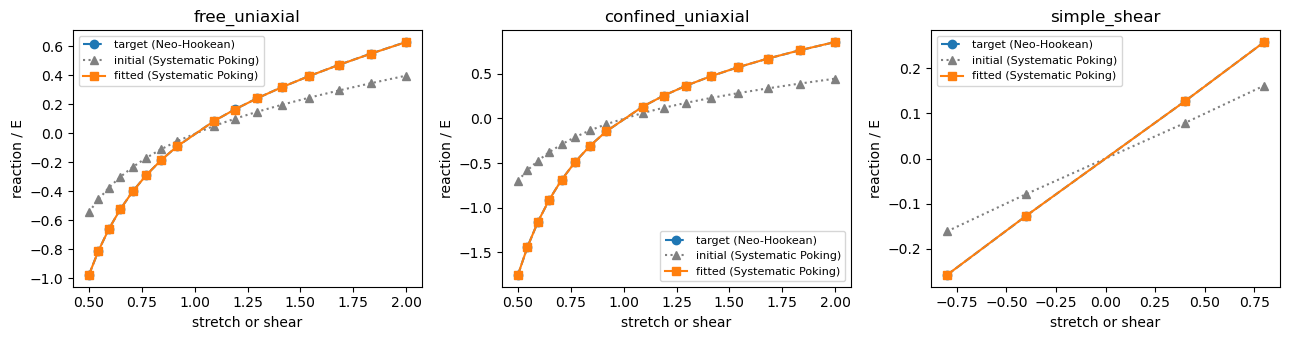

In [12]:
fitted_energy = make_energy(systematic, fitted)
predicted = np.asarray([solve_case(fitted_energy, c)[1] for c in cases])

initial_energy = make_energy(systematic, initial_params)
initial_predicted = np.asarray([solve_case(initial_energy, c)[1] for c in cases])

try:
    import matplotlib.pyplot as plt
    HAS_MPL = True
except Exception:
    HAS_MPL = False

if HAS_MPL:
    fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))
    for ax, protocol in zip(
            axes, ("free_uniaxial", "confined_uniaxial", "simple_shear")):
        sel = np.array([i for i, c in enumerate(cases) if c.protocol == protocol])
        order = np.argsort([cases[i].coordinate for i in sel])
        sel = sel[order]
        x_plot = [cases[i].coordinate for i in sel]
        ax.plot(x_plot, [cases[i].target / FORCE_SCALE for i in sel],
                "o--", label="target (Neo-Hookean)")
        ax.plot(x_plot, [initial_predicted[i] / FORCE_SCALE for i in sel],
                "^:", color="gray", label="initial (Systematic Poking)")
        ax.plot(x_plot, [predicted[i] / FORCE_SCALE for i in sel],
                "s-", label="fitted (Systematic Poking)")
        ax.set_title(protocol)
        ax.set_xlabel("stretch or shear")
        ax.set_ylabel("reaction / E")
        ax.legend(fontsize=8)
    fig.tight_layout()
    plt.show()
else:
    print("matplotlib is not installed; skipping the plot")


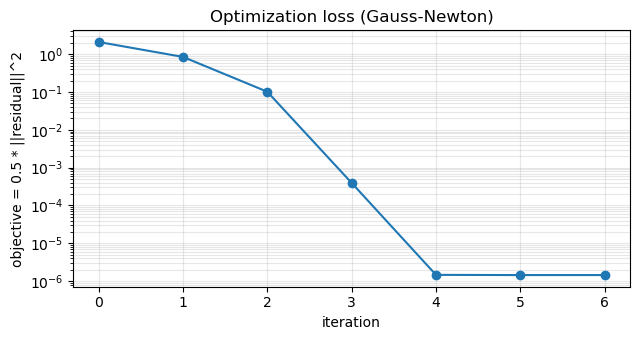

In [13]:
try:
    import matplotlib.pyplot as plt
    HAS_MPL = True
except Exception:
    HAS_MPL = False

if HAS_MPL:
    fig, ax = plt.subplots(figsize=(6.5, 3.5))
    ax.semilogy(
        [h["iteration"] for h in fit_history],
        [h["objective"] for h in fit_history],
        "o-",
    )
    ax.set_xlabel("iteration")
    ax.set_ylabel("objective = 0.5 * ||residual||^2")
    ax.set_title("Optimization loss (Gauss-Newton)")
    ax.grid(True, which="both", alpha=0.3)
    fig.tight_layout()
    plt.show()
else:
    print("matplotlib is not installed; skipping the loss plot")
